# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python
Anaconda3-5.2.0-Windows-x86_64.exe:

Python 3.6.5 |Anaconda, Inc.| (default, Mar 29 2018, 13:32:41) [MSC v.1900 64 bit (AMD64)]

Microsoft Visual Studio Professional 2017 Version 15.8.9

PTVS 15.8.18241.1-15.0

## Install PT3S to site-packages

In [ ]:
### ggf. Rechte erforderlich:  Start-Process powershell -Verb runAs
###!pip uninstall --yes PT3S
###!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [ ]:
###!pip install -e .

## Logging

In [1]:
import logging
import os
logger = logging.getLogger('PT3S')  


logFileName= r"PT3S-Notebook.log"        
loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

## about from PT3S ... import ... and pip install -e .

In [ ]:
#%pwd

In [ ]:
# works only if pip install -e .is NOT active:
###from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [2]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

# ggf. Tests

In [ ]:
%run test.py -q -m 0 -s "^Xm." -s "^Mx."

.
----------------------------------------------------------------------
Ran 1 test in 2.564s

OK
.
----------------------------------------------------------------------
Ran 1 test in 12.168s

OK
.
----------------------------------------------------------------------
Ran 1 test in 2.898s

OK


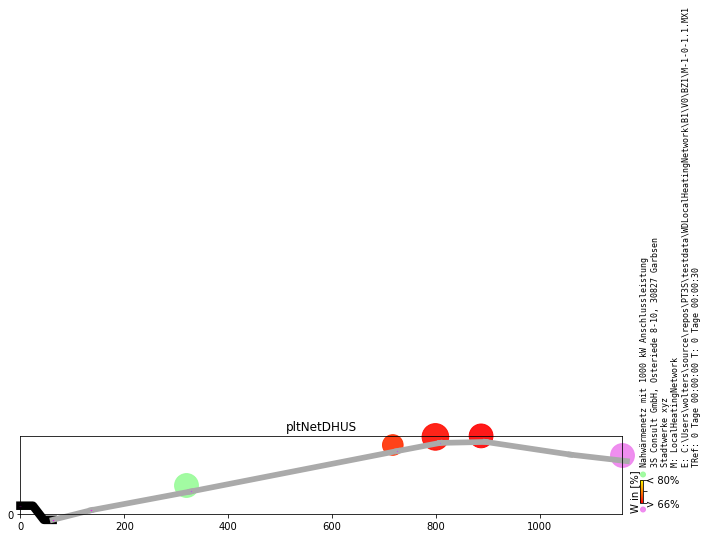

In [4]:
%run test.py -q

In [ ]:
%run test.py -q --testDir testdata10 

.
----------------------------------------------------------------------
Ran 1 test in 2.568s

OK
.
----------------------------------------------------------------------
Ran 1 test in 12.059s

OK
.
----------------------------------------------------------------------
Ran 1 test in 2.958s

OK


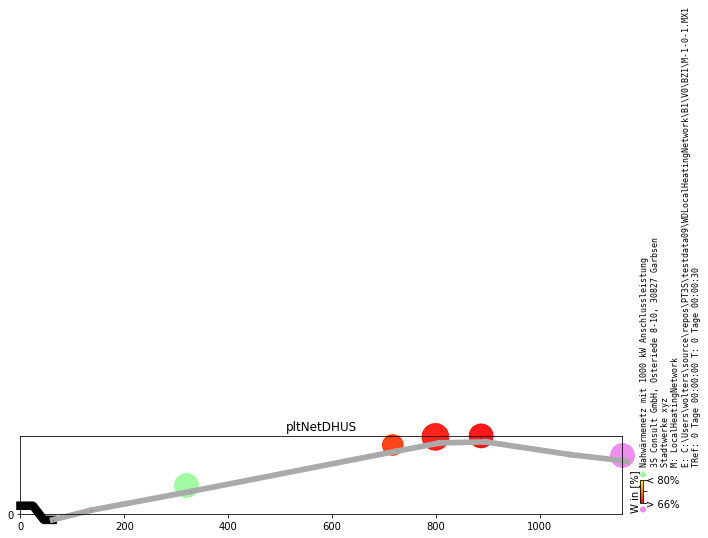

In [3]:
%run test.py -q --testDir testdata09 --dotResolution NONE

# Modell und Ergebnisse laden und nutzen

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import networkx as nx

## Modell

In [ ]:
path='.'
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['BESCHREIBUNG','NAME_i','NAME_k','LAYR','L','D']).sort_index(level=1)

In [ ]:
vVBEL.dtypes

In [ ]:
[viewOrTable for viewOrTable in sorted(xm.dataFrames.keys())]

## Ergebnisse

In [ ]:
(wDir,modelDir,modelName,mx1File)=xm.getWDirModelDirModelName()  

In [ ]:
mx=Mx.Mx(mx1File=mx1File)

### Non-Vector

In [ ]:
mx.df.filter(items=['ALLG~~~4639827058859487185~SNAPSHOTTYPE','KNOT~V-L~~5736262931552588702~PH'])

In [ ]:
mx.df.filter(regex='^KNOT').filter(regex='PH$').plot()

### Vector

In [ ]:
timesReq=mx.df.index.tolist()
mxVecsFileData=mx.getMxsVecsFileData(timesReq)
for vecsFileResult in mxVecsFileData:
    print(vecsFileResult.index)

In [ ]:
vecsFileResult.filter(regex='^ROHR').filter(regex='^(?!.*VEC)')

In [ ]:
vecsFileResult.filter(regex='^KNOT')

## Modell und Ergebnis "synchronisieren"

In [ ]:
xm.MxSync(mx=mx)

In [ ]:
vROHR=xm.dataFrames['vROHR']

In [ ]:
vROHR[['L','mx2NofPts','mx2Idx']]

## Modellsichten um Ergebnisse "ergänzen"

In [ ]:
xm.MxAdd(mx=mx)

### Vektorergebnisse

In [ ]:
vKNOT=xm.dataFrames['vKNOT']
vKNOT.dtypes

In [ ]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['NAME_i','NAME_k','Z_i','KNOT~*~*~*~PH_i','Q']).sort_values(['Q','KNOT~*~*~*~PH_i'], ascending=[1,0])

In [ ]:
vVBEL.dtypes

In [ ]:
vROHR=xm.dataFrames['vROHR']
vROHR.dtypes

In [ ]:
vFWVB=xm.dataFrames['vFWVB']
vFWVB.dtypes

### Rohrvektorergebnisse

In [ ]:
vROHRVecResults=xm.dataFrames['vROHRVecResults']
vROHRVecResults[['pk','mx2Idx','IptIdx','ROHR~*~*~*~SVEC','ROHR~*~*~*~ZVEC','ROHR~*~*~*~MVEC']]

## Schnitte

In [ ]:
vAGSN=xm.dataFrames['vAGSN']

In [ ]:
vAGSN.dtypes

In [ ]:
dfOneVL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
dfOneVL[['OBJTYPE','x','P','Q']]

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['Q'])

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['P'])

## Store in H5

In [ ]:
xm.ToH5()
mx.ToH5()
# next read will be faster because H5 is read instead of XML / MX if H5 is newer than XML / MX

In [ ]:
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
mx=Mx.Mx(mx1File=mx1File)

In [ ]:
#xm?

In [ ]:
#mx?

# Rm Plot Beispiele

In [ ]:
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
    
                 ,pVICsDf=pd.DataFrame({'Kundenname': ['VIC1'],'Knotenname': ['V-K007']})
    
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# NetworkX und SciPy Beispiele

In [ ]:
G=nx.from_pandas_edgelist(xm.dataFrames['vVBEL'], source='NAME_i', target='NAME_k', edge_attr=True,create_using=nx.MultiGraph())

In [ ]:
for e, datadict in G.edges.items():
    print(e)
    print(datadict)

In [ ]:
for n, nbrsdict in G.adj.items():
    print("!{0:s}".format(n))
    for nox, mgdct in nbrsdict.items(): 
        print("   {0:s}".format(nox))
        for mg,edct in  mgdct.items():
            print("        {0:d}: {1:s}".format(mg,str(edct))) 

In [ ]:
print(nx.dijkstra_path(G, 'V-L', 'R-L'))

In [ ]:
max([d for n,d in nx.degree(G)]) 

In [ ]:
spmtx=nx.adjacency_matrix(G) # Return type: SciPy sparse matrix
plt.spy(spmtx)

Die Laplace-Matrix ist definiert als  L:=D-A, wobei  D die Gradmatrix und  A die Adjazenzmatrix des Graphen bezeichnet.

In [ ]:
spmtx=nx.laplacian_matrix(G)
plt.spy(spmtx)

In [ ]:
nl=[n for n in G.nodes()]

In [ ]:
A=nx.to_scipy_sparse_matrix(G)

In [ ]:
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)

In [ ]:
optnl=[nl[idx] for idx in nlo]

In [ ]:
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

## Clean Up

In [ ]:
#xm.delFiles()
#mx.delFiles()

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
###!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git

In [ ]:
xm

In [ ]:
mx

In [ ]:
    def getMxsVecsFileDataAggCalcAggs(df,colsToBeUnpacked):
        """Returns dfAggs, a dataFrame with level 1 Aggregates of MultiIndexed df.
        
        Args:
            df: MultiIndexed dataFrame:
                Level 0: TYPE: TIMESTAMPs or Aggregates (MIN, MAX, ...)
                Level 1: Sir3sID: Sir3sIDs
                col-Labels: mx2Ids; IptIds for Pipe-Vecs
                col-Values: Vec-Values
        """

        #logStr = "{0:s}.{1:s}: ".format(self.__class__.__name__, sys._getframe().f_code.co_name)
        logStr="getMxsVecsFileDataAggTmp: "
        logger.debug("{0:s}{1:s}".format(logStr,'Start.')) 

        import pandas as pd
        try:           
        
            # calc Aggs ---
            dfAggLst=[]
            # MIN
            dfAgg=df.min(level=1)   
            # construct mIndex for Agg
            arrays=[['MIN']*len(colsToBeUnpacked),colsToBeUnpacked]
            tuples = list(zip(*arrays))        
            mIndex = pd.MultiIndex.from_tuples(tuples, names=['TYPE', 'Sir3sID'])     
            dfAggLst.append(pd.DataFrame(dfAgg.values,index=mIndex,columns=dfAgg.columns))
            # MAX
            dfAgg=df.max(level=1)   
            # construct mIndex for Agg
            arrays=[['MAX']*len(colsToBeUnpacked),colsToBeUnpacked]
            tuples = list(zip(*arrays))        
            mIndex = pd.MultiIndex.from_tuples(tuples, names=['TYPE', 'Sir3sID'])     
            dfAggLst.append(pd.DataFrame(dfAgg.values,index=mIndex,columns=dfAgg.columns))            
            dfAggs=pd.concat(dfAggLst) # --- 
            
            
            
            
           
            return dfAggs
        except:
            pass


In [ ]:
    def getMxsVecsFileDataAggTmp(mx,time1st=None,time1stIncluded=True,time2nd=None,time2ndIncluded=True):
        """Returns Aggregates (Min, Max, ...) of mxsVecsFileData between the 2 Times per df.   

        Args:
            * time1st: TIMESTAMP (first if None)
            * time2nd: TIMESTAMP (last if None)
                           
        Returns:
            * dfs with MultiIndex: 
                * Level 0: 'MIN', 'MAX', ...
                * Lecel 1: col (Sir3sID)
                cols: mx2Idx

        Raises:
            MxError        
        """

        #logStr = "{0:s}.{1:s}: ".format(self.__class__.__name__, sys._getframe().f_code.co_name)
        logStr="getMxsVecsFileDataAggTmp: "
        logger.debug("{0:s}{1:s}".format(logStr,'Start.')) 

        import pandas as pd
        try:           
            df=pd.DataFrame()

            if time1st==None:
                time1st=mx.df.index[0]
            if time2nd==None:
                time2nd=mx.df.index[-1]

            if time2nd <= time1st:
                logger.error("{:s}Time2nd: {:s} <= Time1st {:s} ?!".format(logStr,str(time2nd),str(time1st)))    
                raise MxError
           
            if time1st not in mx.df.index:
                logger.error("{:s}Time1st {:s} not available ?!".format(logStr,str(time1st)))    
                raise MxError      
            else:
                time1stIdx=mx.df.index.get_loc(time1st)
                        
            if time2nd not in mx.df.index:
                logger.error("{:s}Time2nd {:s} not available ?!".format(logStr,str(time2nd)))    
                raise MxError   
            else:
                time2ndIdx=mx.df.index.get_loc(time2nd)

            if time2ndIncluded:
                time2ndIncludedOffset=1
            else:
                time2ndIncludedOffset=0
            if time1stIncluded:
                time1stIncludedOffset=0
            else:
                time1stIncludedOffset=1
            timesReq=list(mx.df.index[time1stIdx+time1stIncludedOffset:time2ndIdx+time2ndIncludedOffset])  
            
            # read the 1st Time
            mxVecsFileDataLst=mx.getMxsVecsFileData(timesReq=[timesReq[0]])
            mxVecsFileData=mxVecsFileDataLst[0]
            # unpack it
            colsToBeUnpacked=mxVecsFileData.columns.tolist()
            arrays=[[mxVecsFileData.index[0]]*len(colsToBeUnpacked),colsToBeUnpacked]
            tuples = list(zip(*arrays))        
            mIndex = pd.MultiIndex.from_tuples(tuples, names=['TYPE', 'Sir3sID'])               
            # store it with Time (create the df)
            df=mx.unPackMxsVecsFileDataDf(mxVecsFileData,mIndex)
            

            
            
            dfAggs=getMxsVecsFileDataAggCalcAggs(df,colsToBeUnpacked)
            
            # store Aggs with Agg
            
            
            
            df=pd.concat([df,dfAggs])
            # 1 TIMETAMP 
            # all Aggregates
            
            oldTime=timesReq[0]
            

            print(oldTime)
            for time in timesReq[1:]:
                print(time)
                # drop oldTime
                df.drop(oldTime,level=0,inplace=True)
                # add new Time
                # read it
                mxVecsFileDataLst=mx.getMxsVecsFileData(timesReq=[time])
                mxVecsFileData=mxVecsFileDataLst[0]
                # unpack ...
                colsToBeUnpacked=mxVecsFileData.columns.tolist()
                arrays=[[mxVecsFileData.index[0]]*len(colsToBeUnpacked),colsToBeUnpacked]
                tuples = list(zip(*arrays))        
                mIndex = pd.MultiIndex.from_tuples(tuples, names=['TYPE', 'Sir3sID'])               
                # ... and store it  
                df=pd.concat([df,mx.unPackMxsVecsFileDataDf(mxVecsFileData,mIndex)])
                
                # df:
                # 1 (new) TIMETAMP 
                # all (old) Aggs
                dfAggs=getMxsVecsFileDataAggCalcAggs(df,colsToBeUnpacked)
                
                # drop old Aggs
                df.drop('MIN',level=0,inplace=True)
                df.drop('MAX',level=0,inplace=True)
            
                # store new Agg
                df=pd.concat([df,dfAggs])
                # 1 TIMETAMP 
                # all Aggregates                
                
                
                
                oldTime=time
                
            df.drop(oldTime,level=0,inplace=True)
            return df
        except:
            pass


In [ ]:
getMxsVecsFileDataAggTmp(mx)